<a href="https://colab.research.google.com/github/huamanchristian44/LAB04/blob/develop/Laboratorio_04_Mineria_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install ucimlrepo

In [2]:
import missingno as msno
import matplotlib.pyplot as plt
from pandas import set_option
import pandas as pd
from sklearn import preprocessing
from scipy.spatial.distance import mahalanobis
from sklearn.preprocessing import MinMaxScaler
import math
import numpy as np
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

In [4]:
# Almacenar en un solo dataframe
data_mama = pd.concat([X, y], axis=1)

In [5]:
data_mama.head()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


In [6]:
data_mama.shape

(699, 10)

a. Por medio de la librería ‘Pandas’, lea la base de datos, asigne nombres para las columnas,
realice una imputación para la variable ‘Bare Nuclei’ por medio de la mediana y cambie las
categorías para la variable ‘Class’ de 2 o 4 por 0 o 1.


In [7]:
data_mama.describe()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [8]:
data_mama.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


In [9]:
# columnas con missings
columnas_nulas=data_mama.columns[data_mama.isnull().any()]
print(columnas_nulas)

Index(['Bare_nuclei'], dtype='object')


In [10]:
# número de missings por columna
data_mama.isnull().sum()

,0
Clump_thickness,0
Uniformity_of_cell_size,0
Uniformity_of_cell_shape,0
Marginal_adhesion,0
Single_epithelial_cell_size,0
Bare_nuclei,16
Bland_chromatin,0
Normal_nucleoli,0
Mitoses,0
Class,0


<Axes: >

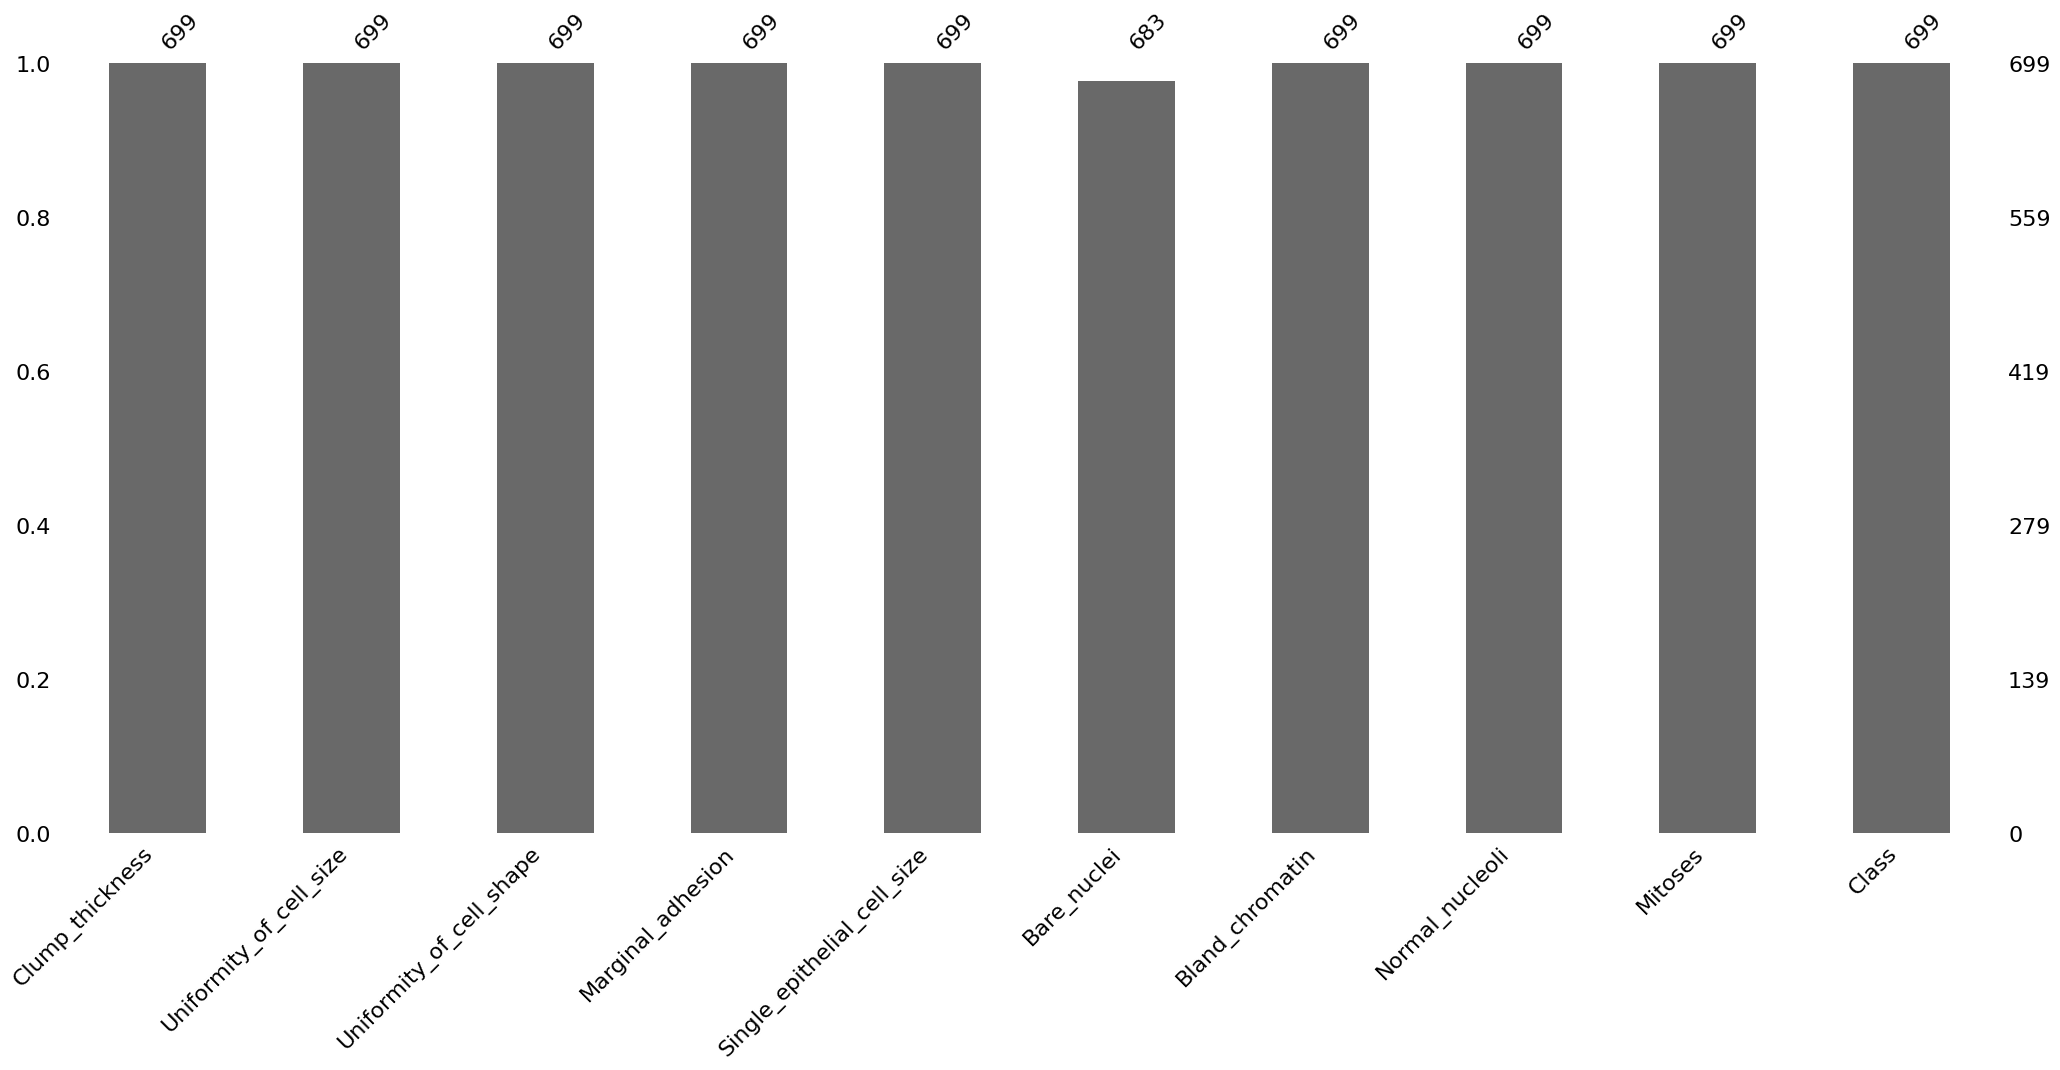

In [11]:
msno.bar(data_mama)

In [13]:
data_mama['Bare_nuclei'] = pd.to_numeric(data_mama['Bare_nuclei'], errors='coerce')
data_mama['Bare_nuclei'].fillna(data_mama['Bare_nuclei'].median(), inplace=True)

<ipython-input-13-6325d4e15b4e>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_mama['Bare_nuclei'].fillna(data_mama['Bare_nuclei'].median(), inplace=True)


<Axes: >

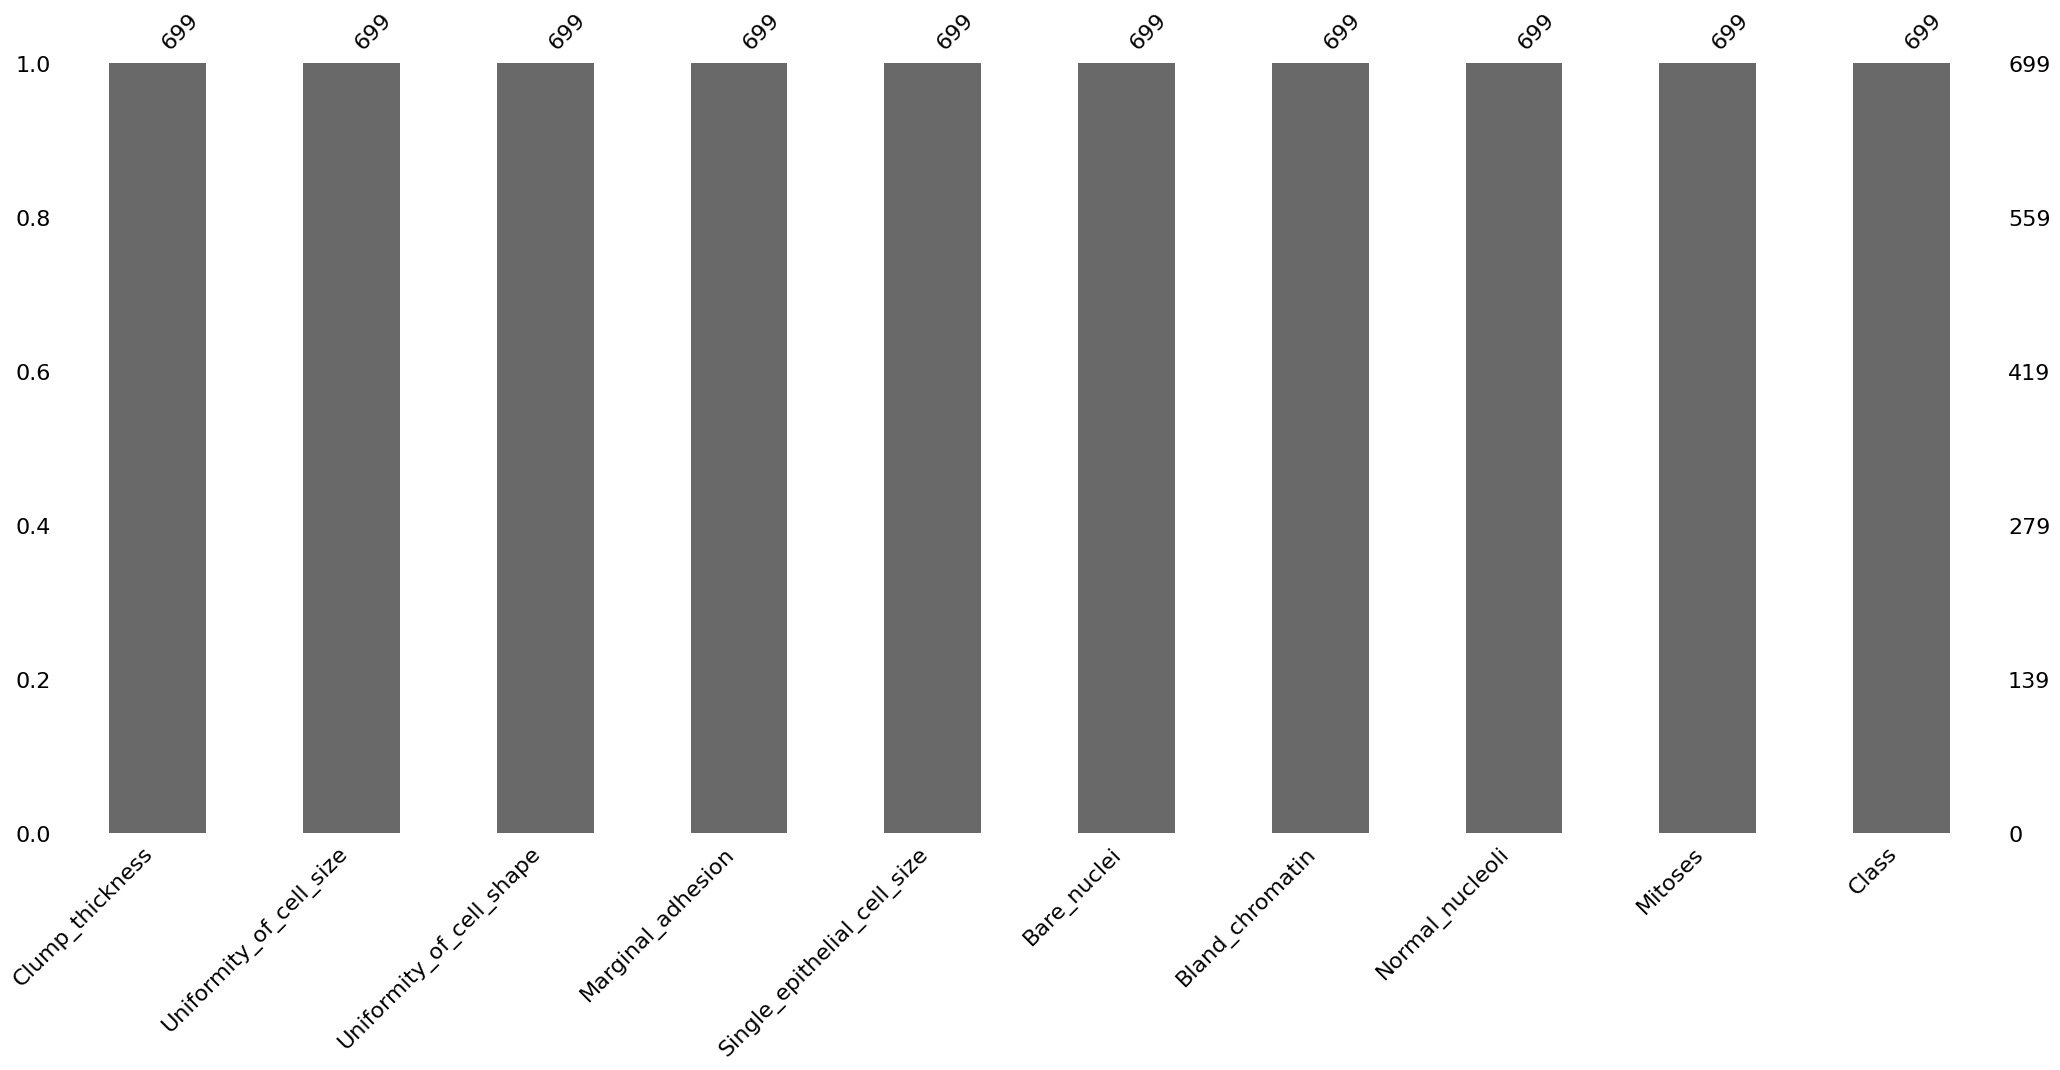

In [14]:
msno.bar(data_mama)

In [15]:
data_mama['Bare_nuclei'].describe()

,Bare_nuclei
count,699.000000
mean,3.486409
std,3.621929
min,1.000000
25%,1.000000
50%,1.000000
75%,5.000000
max,10.000000


In [16]:
#Cambiando clases
data_mama['Class'] = data_mama['Class'].replace({2: 0, 4: 1})

b. Realice una detección de valores atípicos univariados por medio del método del rango
intercuartílico con 3 de longitud a la derecha y 3 a la izquierda, y elimínelos. Además, realice
una detección de valores atípicos multivariados por medio de las distancias de Mahalanobis y
elimine aquellos valores que superen el valor de 30.


Detección univariada por rango intercuartílico (IQR)

In [17]:
def eliminar_outliers_iqr(df, k=3):
    df_limpio = df.copy()
    columnas_numericas = df.select_dtypes(include=[np.number]).columns
    for col in columnas_numericas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - k * IQR
        lim_sup = Q3 + k * IQR
        df_limpio = df_limpio[(df_limpio[col] >= lim_inf) & (df_limpio[col] <= lim_sup)]
    return df_limpio

data_mama = eliminar_outliers_iqr(data_mama, k=3)

Detección multivariada por distancia de Mahalanobis

In [19]:
def calcular_mahalanobis(df):
    columnas_excluir = ['Sample_code_number', 'Class']
    columnas_numericas = df.select_dtypes(include=[np.number]).columns
    columnas_uso = [col for col in columnas_numericas if col not in columnas_excluir]

    X = df[columnas_uso]
    cov_matrix = np.cov(X, rowvar=False)

    # Usar pseudoinversa en lugar de inversa para evitar problemas con matrices singulares
    inv_cov_matrix = np.linalg.pinv(cov_matrix)

    mean_datos = X.mean(axis=0).values
    distancias = X.apply(lambda row: mahalanobis(row.values, mean_datos, inv_cov_matrix), axis=1)
    return distancias

In [20]:
dist_mahalanobis = calcular_mahalanobis(data_mama)
data_mama = data_mama[dist_mahalanobis < 30]

In [21]:
print(dist_mahalanobis)

0      1.554676
1      4.109994
2      1.036298
3      4.666024
4      1.635072
         ...   
692    0.953395
694    1.354956
695    1.026812
697    4.955199
698    4.617549
Length: 579, dtype: float64


c. Realice un cálculo de los principales estadísticos descriptivos para las variables predictoras y
cree dos conjuntos de datos: uno en donde se aplique la transformación Z-score y otro en
donde se aplique la normalización mín-máx, sobre todas las variables predictoras

Estadísticos descriptivos

In [22]:
set_option('display.float_format', lambda x: '%.2f' % x)
estadisticas = data_mama.describe()
print(estadisticas)

       Clump_thickness  Uniformity_of_cell_size  Uniformity_of_cell_shape  \
count           579.00                   579.00                    579.00   
mean              3.85                     2.45                      2.58   
std               2.53                     2.59                      2.55   
min               1.00                     1.00                      1.00   
25%               2.00                     1.00                      1.00   
50%               3.00                     1.00                      1.00   
75%               5.00                     3.00                      3.00   
max              10.00                    10.00                     10.00   

       Marginal_adhesion  Single_epithelial_cell_size  Bare_nuclei  \
count             579.00                       579.00       579.00   
mean                2.22                         2.75         2.72   
std                 2.32                         1.81         3.15   
min                 1.00  

Variables predictoras sin 'Class'

In [23]:
X_predictoras = data_mama.drop(['Class'], axis=1)
X_predictoras

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,5,1,1,1,2,1.00,3,1,1
1,5,4,4,5,7,10.00,3,2,1
2,3,1,1,1,2,2.00,3,1,1
3,6,8,8,1,3,4.00,3,7,1
4,4,1,1,3,2,1.00,3,1,1
...,...,...,...,...,...,...,...,...,...
692,3,1,1,1,2,1.00,1,1,1
694,3,1,1,1,3,2.00,1,1,1
695,2,1,1,1,2,1.00,1,1,1
697,4,8,6,4,3,4.00,10,6,1


Transformación Z-score

In [24]:
X_zscore = X_predictoras.apply(lambda x: (x - x.mean()) / x.std())
X_zscore

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,0.45,-0.56,-0.62,-0.53,-0.42,-0.54,-0.00,-0.48,NaN
1,0.45,0.60,0.56,1.20,2.35,2.31,-0.00,-0.07,NaN
2,-0.34,-0.56,-0.62,-0.53,-0.42,-0.23,-0.00,-0.48,NaN
3,0.85,2.15,2.13,-0.53,0.14,0.41,-0.00,1.93,NaN
4,0.06,-0.56,-0.62,0.34,-0.42,-0.54,-0.00,-0.48,NaN
...,...,...,...,...,...,...,...,...,...
692,-0.34,-0.56,-0.62,-0.53,-0.42,-0.54,-0.91,-0.48,NaN
694,-0.34,-0.56,-0.62,-0.53,0.14,-0.23,-0.91,-0.48,NaN
695,-0.73,-0.56,-0.62,-0.53,-0.42,-0.54,-0.91,-0.48,NaN
697,0.06,2.15,1.34,0.77,0.14,0.41,3.18,1.53,NaN


Transformación min-max

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_minmax = scaler.fit_transform(X_predictoras)
X_minmax = pd.DataFrame(X_minmax, columns=X_predictoras.columns)
X_minmax

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,0.44,0.00,0.00,0.00,0.11,0.00,0.22,0.00,0.00
1,0.44,0.33,0.33,0.44,0.67,1.00,0.22,0.11,0.00
2,0.22,0.00,0.00,0.00,0.11,0.11,0.22,0.00,0.00
3,0.56,0.78,0.78,0.00,0.22,0.33,0.22,0.67,0.00
4,0.33,0.00,0.00,0.22,0.11,0.00,0.22,0.00,0.00
...,...,...,...,...,...,...,...,...,...
574,0.22,0.00,0.00,0.00,0.11,0.00,0.00,0.00,0.00
575,0.22,0.00,0.00,0.00,0.22,0.11,0.00,0.00,0.00
576,0.11,0.00,0.00,0.00,0.11,0.00,0.00,0.00,0.00
577,0.33,0.78,0.56,0.33,0.22,0.33,1.00,0.56,0.00
